# CNN + DANN + Per-Component RUL Predictor
**Dataset:** `EV_Predictive_Maintenance_Dataset_15min.csv`  
**Task:** Domain-adaptive RUL prediction for 5 EV components simultaneously

```
Input (24 sensors × 20 timesteps)
          │
   CNN Feature Extractor  (shared)
          │
    ┌─────┼──────────────────────────────┐
    │     │                              │
 Battery Motor  Brakes  Tires  Suspension   GRL → Domain Discriminator
  Head   Head   Head    Head     Head
  (RUL)  (RUL)  (RUL)   (RUL)    (RUL)
```

## 1. Imports & Config

In [1]:
import math, warnings, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.autograd import Function

warnings.filterwarnings('ignore')
os.makedirs('../results', exist_ok=True)
os.makedirs('../models',  exist_ok=True)

# ── Hyperparameters ──────────────────────────────────────────────────
WINDOW_SIZE  = 20
BATCH_SIZE   = 64
EPOCHS       = 60
LR           = 1e-3
LAMBDA_MAX   = 1.0
MAX_RUL      = 300.0
DOMAIN_SPLIT = 0.6
SEED         = 42

torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

# ── Component sensor groups ──────────────────────────────────────────
COMPONENTS = {
    'Battery':    ['SoC', 'SoH', 'Battery_Voltage', 'Battery_Current',
                   'Battery_Temperature', 'Charge_Cycles'],
    'Motor':      ['Motor_Temperature', 'Motor_Vibration',
                   'Motor_Torque', 'Motor_RPM', 'Power_Consumption'],
    'Brakes':     ['Brake_Pad_Wear', 'Brake_Pressure', 'Reg_Brake_Efficiency'],
    'Tires':      ['Tire_Pressure', 'Tire_Temperature'],
    'Suspension': ['Suspension_Load', 'Route_Roughness'],
}
COMPONENT_NAMES = list(COMPONENTS.keys())

# All sensor columns (all components combined)
SENSOR_COLS = [
    'SoC', 'SoH', 'Battery_Voltage', 'Battery_Current',
    'Battery_Temperature', 'Charge_Cycles', 'Motor_Temperature',
    'Motor_Vibration', 'Motor_Torque', 'Motor_RPM', 'Power_Consumption',
    'Brake_Pad_Wear', 'Brake_Pressure', 'Reg_Brake_Efficiency',
    'Tire_Pressure', 'Tire_Temperature', 'Suspension_Load',
    'Ambient_Temperature', 'Ambient_Humidity', 'Load_Weight',
    'Driving_Speed', 'Distance_Traveled', 'Idle_Time', 'Route_Roughness'
]
N_SENSORS = len(SENSOR_COLS)
N_COMPONENTS = len(COMPONENTS)

print(f'Sensors      : {N_SENSORS}')
print(f'Components   : {COMPONENT_NAMES}')

Device: cpu
Sensors      : 24
Components   : ['Battery', 'Motor', 'Brakes', 'Tires', 'Suspension']


## 2. Load & Preprocess

In [2]:
CSV_PATH = '../data/EV_Predictive_Maintenance_Dataset_15min.csv'

df = pd.read_csv(CSV_PATH)
df = df.ffill().bfill()
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp').reset_index(drop=True)
df['RUL'] = df['RUL'].clip(upper=MAX_RUL)

print(f'Shape : {df.shape}')
print(f'RUL   : {df["RUL"].min():.2f} to {df["RUL"].max():.2f}')

# ── Derive per-component RUL proxies from domain knowledge ───────────
# Each component RUL is a weighted combination of its own degradation signals,
# normalised so they all share the same [0, MAX_RUL] range as the global RUL.

def norm01(s):
    """Min-max normalise a Series to [0, 1]."""
    mn, mx = s.min(), s.max()
    return (s - mn) / (mx - mn + 1e-8)

# Battery RUL: driven by SoH degradation and charge cycles
# Low SoH  → low remaining life; high charge cycles → low remaining life
df['RUL_Battery'] = (
    0.6 * norm01(df['SoH']) +
    0.4 * (1 - norm01(df['Charge_Cycles']))
) * MAX_RUL

# Motor RUL: driven by vibration and temperature stress
# High vibration / high temperature → lower remaining life
df['RUL_Motor'] = (
    0.5 * (1 - norm01(df['Motor_Vibration'])) +
    0.3 * (1 - norm01(df['Motor_Temperature'])) +
    0.2 * (1 - norm01(df['Motor_Torque']))
) * MAX_RUL

# Brakes RUL: driven by pad wear and pressure
# High brake pad wear → near end of life
df['RUL_Brakes'] = (
    0.7 * (1 - norm01(df['Brake_Pad_Wear'])) +
    0.3 * norm01(df['Reg_Brake_Efficiency'])
) * MAX_RUL

# Tires RUL: driven by pressure loss and temperature
df['RUL_Tires'] = (
    0.6 * norm01(df['Tire_Pressure']) +
    0.4 * (1 - norm01(df['Tire_Temperature']))
) * MAX_RUL

# Suspension RUL: driven by load and route roughness
df['RUL_Suspension'] = (
    0.5 * (1 - norm01(df['Suspension_Load'])) +
    0.5 * (1 - norm01(df['Route_Roughness']))
) * MAX_RUL

COMPONENT_RUL_COLS = [f'RUL_{c}' for c in COMPONENT_NAMES]
print('\nComponent RUL ranges:')
for col in COMPONENT_RUL_COLS:
    print(f'  {col:20s}: {df[col].min():.1f} – {df[col].max():.1f}')

Shape : (175393, 30)
RUL   : 0.00 to 300.00

Component RUL ranges:
  RUL_Battery         : 0.2 – 300.0
  RUL_Motor           : 10.9 – 298.9
  RUL_Brakes          : 1.3 – 299.8
  RUL_Tires           : 1.6 – 299.9
  RUL_Suspension      : 0.1 – 299.8


## 3. EDA

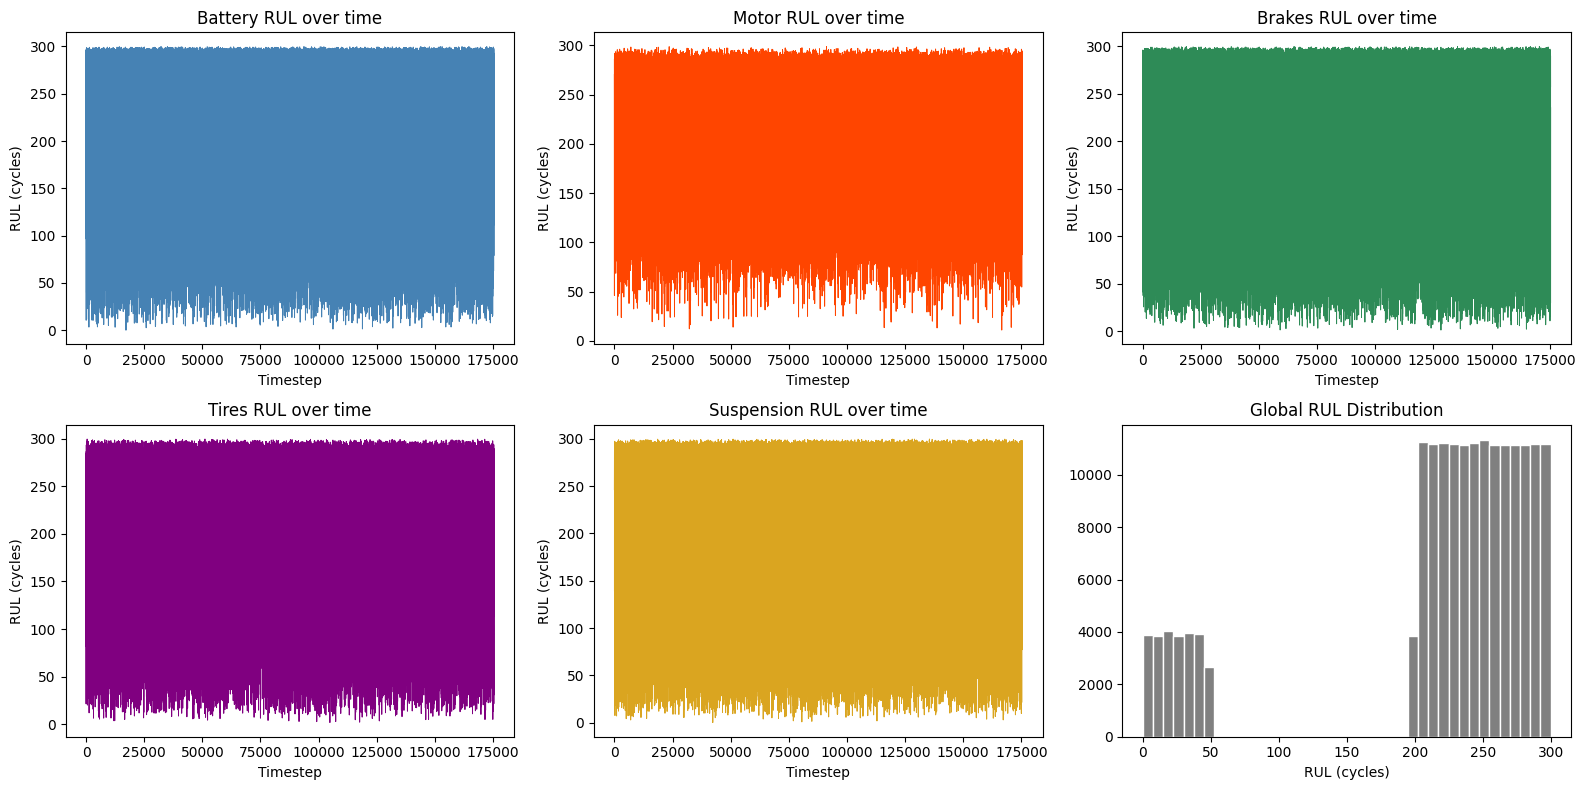

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

colors = ['steelblue', 'orangered', 'seagreen', 'purple', 'goldenrod']

for i, (comp, col, color) in enumerate(zip(COMPONENT_NAMES, COMPONENT_RUL_COLS, colors)):
    axes[i].plot(df[col].values, color=color, linewidth=0.7)
    axes[i].set_title(f'{comp} RUL over time')
    axes[i].set_xlabel('Timestep')
    axes[i].set_ylabel('RUL (cycles)')

# Global RUL in last panel
axes[5].hist(df['RUL'], bins=40, color='gray', edgecolor='white')
axes[5].set_title('Global RUL Distribution')
axes[5].set_xlabel('RUL (cycles)')

plt.tight_layout()
plt.savefig('../results/component_rul_eda.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Domain Split & Normalisation

In [4]:
split_idx = int(len(df) * DOMAIN_SPLIT)
df_src = df.iloc[:split_idx].copy().reset_index(drop=True)
df_tgt = df.iloc[split_idx:].copy().reset_index(drop=True)

print(f'Source rows: {len(df_src)}')
print(f'Target rows: {len(df_tgt)}')

# Normalise sensors
scaler = MinMaxScaler()
scaler.fit(df_src[SENSOR_COLS])
df_src[SENSOR_COLS] = scaler.transform(df_src[SENSOR_COLS])
df_tgt[SENSOR_COLS] = scaler.transform(df_tgt[SENSOR_COLS])

# Normalise each component RUL to [0, 1]
for col in COMPONENT_RUL_COLS:
    norm_col = col + '_norm'
    df_src[norm_col] = df_src[col] / MAX_RUL
    df_tgt[norm_col] = df_tgt[col] / MAX_RUL

COMPONENT_RUL_NORM_COLS = [c + '_norm' for c in COMPONENT_RUL_COLS]
print('Normalised RUL columns:', COMPONENT_RUL_NORM_COLS)

Source rows: 105235
Target rows: 70158
Normalised RUL columns: ['RUL_Battery_norm', 'RUL_Motor_norm', 'RUL_Brakes_norm', 'RUL_Tires_norm', 'RUL_Suspension_norm']


## 5. Sliding-Window Dataset

In [5]:
def make_windows(df, sensor_cols, rul_norm_cols, window_size=WINDOW_SIZE):
    """
    Returns:
        X : (N, window_size, n_sensors)   float32
        Y : (N, n_components)             float32  — one normalised RUL per component
    """
    vals = df[sensor_cols].values.astype(np.float32)
    ruls = df[rul_norm_cols].values.astype(np.float32)  # (rows, n_components)
    X, Y = [], []
    for i in range(window_size, len(vals) + 1):
        X.append(vals[i - window_size : i])
        Y.append(ruls[i - 1])                           # RUL at last timestep
    return np.array(X), np.array(Y)


X_src, Y_src = make_windows(df_src, SENSOR_COLS, COMPONENT_RUL_NORM_COLS)
X_tgt, Y_tgt = make_windows(df_tgt, SENSOR_COLS, COMPONENT_RUL_NORM_COLS)

print(f'Source  X: {X_src.shape}  Y: {Y_src.shape}')
print(f'Target  X: {X_tgt.shape}  Y: {Y_tgt.shape}')

Source  X: (105216, 20, 24)  Y: (105216, 5)
Target  X: (70139, 20, 24)  Y: (70139, 5)


In [6]:
class EVDataset(Dataset):
    """
    __getitem__ returns:
        x : Tensor (n_sensors, window)    — CNN input
        y : Tensor (n_components,)        — per-component normalised RUL
        d : Tensor (1,)                   — domain label
    """
    def __init__(self, X, Y, domain_label):
        self.X = torch.tensor(X).permute(0, 2, 1)       # (N, sensors, window)
        self.Y = torch.tensor(Y)                         # (N, n_components)
        self.d = torch.full((len(X), 1), float(domain_label))

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx], self.d[idx]


src_dataset = EVDataset(X_src, Y_src, domain_label=0)
tgt_dataset = EVDataset(X_tgt, Y_tgt, domain_label=1)

src_train_size = int(0.8 * len(src_dataset))
src_val_size   = len(src_dataset) - src_train_size
src_train, src_val = torch.utils.data.random_split(
    src_dataset, [src_train_size, src_val_size],
    generator=torch.Generator().manual_seed(SEED)
)

src_train_loader = DataLoader(src_train,   batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
src_val_loader   = DataLoader(src_val,     batch_size=BATCH_SIZE, shuffle=False)
tgt_train_loader = DataLoader(tgt_dataset, batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
tgt_val_loader   = DataLoader(tgt_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Source train batches : {len(src_train_loader)}')
print(f'Source val   batches : {len(src_val_loader)}')
print(f'Target       batches : {len(tgt_train_loader)}')

Source train batches : 1315
Source val   batches : 329
Target       batches : 1095


## 6. Model Architecture

### 6.1 Gradient Reversal Layer

In [7]:
class GradientReversalFn(Function):
    @staticmethod
    def forward(ctx, x, lam):
        ctx.lam = lam
        return x.clone()

    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lam * grad_output, None


class GRL(nn.Module):
    def __init__(self):
        super().__init__()
        self.lam = 0.0

    def set_lambda(self, lam):
        self.lam = lam

    def forward(self, x):
        return GradientReversalFn.apply(x, self.lam)

### 6.2 Shared CNN Feature Extractor

In [9]:
class CNNFeatureExtractor(nn.Module):
    """
    Shared across all components and the domain discriminator.
    Input  : (batch, 24, 20)
    Output : (batch, 128)
    """
    def __init__(self, n_sensors=N_SENSORS):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(n_sensors, 64,  kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),                  # (64, 10)

            nn.Conv1d(64,  128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),                  # (128, 5)

            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),          # (128, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)        # (batch, 128)

### 6.3 Per-Component RUL Heads

In [10]:
class ComponentRULHead(nn.Module):
    """
    One small FC head per component.
    Input  : (batch, 128)
    Output : (batch, 1)  normalised RUL in [0, 1]
    """
    def __init__(self, feat_dim=128, name=''):
        super().__init__()
        self.name = name
        self.net = nn.Sequential(
            nn.Linear(feat_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

### 6.4 Domain Discriminator

In [11]:
class DomainDiscriminator(nn.Module):
    """
    Input  : (batch, 128)  — after GRL
    Output : (batch, 1)    — domain logit
    """
    def __init__(self, feat_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feat_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

### 6.5 Full DANN Model with 5 RUL Heads

In [12]:
class MultiComponentDANN(nn.Module):
    """
    One shared CNN + one RUL head per component + one domain discriminator.

    Forward returns:
        rul_preds   : (batch, n_components)  — stacked per-component RUL
        domain_pred : (batch, 1)             — domain logit
    """
    def __init__(self, component_names=COMPONENT_NAMES):
        super().__init__()
        self.feature_extractor    = CNNFeatureExtractor()
        self.grl                  = GRL()
        self.domain_discriminator = DomainDiscriminator()

        # One head per component, stored in a ModuleDict so PyTorch tracks them
        self.rul_heads = nn.ModuleDict({
            name: ComponentRULHead(name=name)
            for name in component_names
        })

    def forward(self, x):
        features = self.feature_extractor(x)              # (batch, 128)

        # Per-component RUL predictions
        rul_preds = torch.cat(
            [self.rul_heads[name](features) for name in COMPONENT_NAMES],
            dim=1
        )                                                  # (batch, n_components)

        # Domain prediction via reversed gradients
        domain_pred = self.domain_discriminator(self.grl(features))

        return rul_preds, domain_pred


model = MultiComponentDANN().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')
print()
print('RUL heads:')
for name in COMPONENT_NAMES:
    n = sum(p.numel() for p in model.rul_heads[name].parameters())
    print(f'  {name:12s}: {n:,} params')

Trainable parameters: 141,510

RUL heads:
  Battery     : 10,369 params
  Motor       : 10,369 params
  Brakes      : 10,369 params
  Tires       : 10,369 params
  Suspension  : 10,369 params


## 7. Training Loop

In [ ]:
rul_criterion    = nn.MSELoss()
domain_criterion = nn.BCEWithLogitsLoss()
optimizer        = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler        = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


def grl_lambda(epoch, total_epochs, max_lambda=LAMBDA_MAX):
    p = epoch / total_epochs
    return max_lambda * (2.0 / (1.0 + math.exp(-10 * p)) - 1)


# Track loss per component + domain
history = {
    'train_rul': [], 'val_rul': [], 'train_dom': [],
    **{f'val_rmse_{c}': [] for c in COMPONENT_NAMES}
}

for epoch in range(1, EPOCHS + 1):
    model.train()
    lam = grl_lambda(epoch, EPOCHS)
    model.grl.set_lambda(lam)

    train_rul_loss = 0.0
    train_dom_loss = 0.0
    tgt_iter = iter(tgt_train_loader)

    for src_batch in src_train_loader:
        x_src, y_src_b, d_src = [t.to(DEVICE) for t in src_batch]

        try:
            tgt_batch = next(tgt_iter)
        except StopIteration:
            tgt_iter = iter(tgt_train_loader)
            tgt_batch = next(tgt_iter)
        x_tgt, _, d_tgt = [t.to(DEVICE) for t in tgt_batch]

        optimizer.zero_grad()

        # Source: predict all component RULs + domain
        rul_preds_src, dom_pred_src = model(x_src)
        # Average MSE across all component heads
        loss_rul     = rul_criterion(rul_preds_src, y_src_b)
        loss_dom_src = domain_criterion(dom_pred_src, d_src)

        # Target: domain only
        _, dom_pred_tgt = model(x_tgt)
        loss_dom_tgt = domain_criterion(dom_pred_tgt, d_tgt)

        loss_domain = (loss_dom_src + loss_dom_tgt) / 2.0
        total_loss  = loss_rul + loss_domain

        total_loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_rul_loss += loss_rul.item()
        train_dom_loss += loss_domain.item()

    scheduler.step()

    # ── Validation ──────────────────────────────────────────────────
    model.eval()
    val_preds_all  = []
    val_labels_all = []
    val_rul_loss   = 0.0

    with torch.no_grad():
        for x_val, y_val, _ in src_val_loader:
            x_val, y_val = x_val.to(DEVICE), y_val.to(DEVICE)
            preds, _ = model(x_val)
            val_rul_loss += rul_criterion(preds, y_val).item()
            val_preds_all.append(preds.cpu().numpy())
            val_labels_all.append(y_val.cpu().numpy())

    val_preds_all  = np.concatenate(val_preds_all)  * MAX_RUL  # (N, 5)
    val_labels_all = np.concatenate(val_labels_all) * MAX_RUL

    # Per-component RMSE
    component_rmse = {}
    for i, name in enumerate(COMPONENT_NAMES):
        rmse = math.sqrt(mean_squared_error(val_labels_all[:, i], val_preds_all[:, i]))
        component_rmse[name] = rmse
        history[f'val_rmse_{name}'].append(rmse)

    avg_train_rul = train_rul_loss / len(src_train_loader)
    avg_train_dom = train_dom_loss / len(src_train_loader)
    avg_val_rul   = val_rul_loss   / len(src_val_loader)

    history['train_rul'].append(avg_train_rul)
    history['train_dom'].append(avg_train_dom)
    history['val_rul'].append(avg_val_rul)

    if epoch % 10 == 0 or epoch == 1:
        rmse_str = '  '.join([f'{n}={v:.1f}' for n, v in component_rmse.items()])
        print(f'Epoch {epoch:3d}/{EPOCHS} | lam={lam:.2f} | '
              f'Train RUL={avg_train_rul:.4f} Dom={avg_train_dom:.4f} | '
              f'Val RMSE → {rmse_str}')

## 8. Training Curves

NameError: name 'history' is not defined

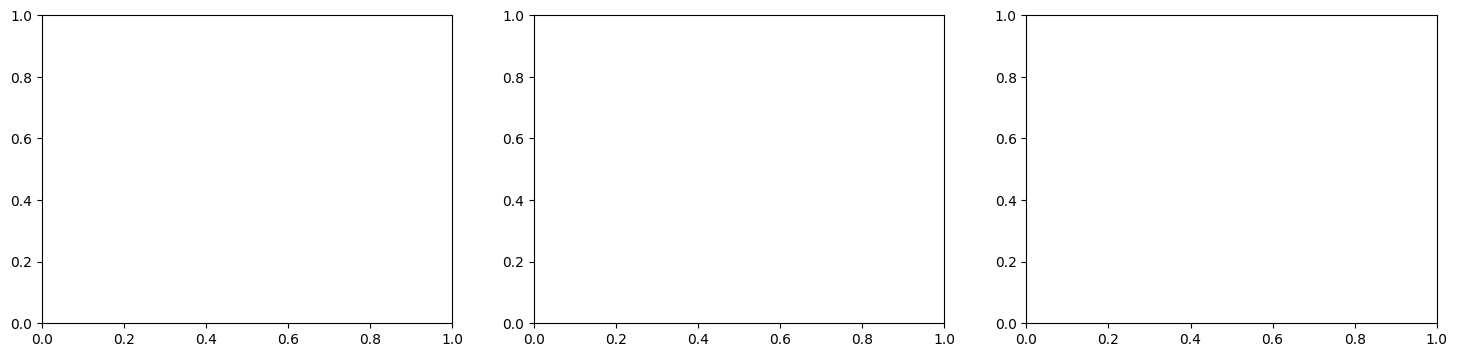

In [13]:
ep = range(1, EPOCHS + 1)
colors = ['steelblue', 'orangered', 'seagreen', 'purple', 'goldenrod']

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(ep, history['train_rul'], label='Train RUL loss')
axes[0].plot(ep, history['val_rul'],   label='Val RUL loss')
axes[0].set_title('RUL Loss (MSE, all components)'); axes[0].legend()

axes[1].plot(ep, history['train_dom'], color='gray')
axes[1].set_title('Domain Discriminator Loss')

for name, color in zip(COMPONENT_NAMES, colors):
    axes[2].plot(ep, history[f'val_rmse_{name}'], label=name, color=color)
axes[2].set_title('Val RMSE per Component (cycles)')
axes[2].legend(fontsize=8)

for ax in axes:
    ax.set_xlabel('Epoch')

plt.tight_layout()
plt.savefig('../results/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Evaluation

In [14]:
def evaluate(loader, model, device, component_names=COMPONENT_NAMES, max_rul=MAX_RUL):
    model.eval()
    preds_all, labels_all = [], []
    with torch.no_grad():
        for x, y, _ in loader:
            x = x.to(device)
            preds, _ = model(x)
            preds_all.append(preds.cpu().numpy())
            labels_all.append(y.numpy())

    preds_all  = np.concatenate(preds_all)  * max_rul   # (N, 5)
    labels_all = np.concatenate(labels_all) * max_rul

    results = {}
    for i, name in enumerate(component_names):
        p, l = preds_all[:, i], labels_all[:, i]
        rmse  = math.sqrt(mean_squared_error(l, p))
        mae   = float(np.mean(np.abs(p - l)))
        diff  = p - l
        score = float(np.sum(np.where(diff < 0,
                                      np.exp(-diff / 13) - 1,
                                      np.exp( diff / 10) - 1)))
        results[name] = {'rmse': rmse, 'mae': mae, 'score': score,
                         'preds': p, 'labels': l}
    return results


src_results = evaluate(src_val_loader, model, DEVICE)
tgt_results = evaluate(tgt_val_loader, model, DEVICE)

# Summary table
rows = []
for name in COMPONENT_NAMES:
    rows.append({
        'Component'  : name,
        'Src RMSE'   : round(src_results[name]['rmse'],  2),
        'Src MAE'    : round(src_results[name]['mae'],   2),
        'Tgt RMSE'   : round(tgt_results[name]['rmse'],  2),
        'Tgt MAE'    : round(tgt_results[name]['mae'],   2),
        'Tgt Score'  : round(tgt_results[name]['score'], 1),
    })

summary = pd.DataFrame(rows).set_index('Component')
print(summary.to_string())

            Src RMSE  Src MAE  Tgt RMSE  Tgt MAE     Tgt Score
Component                                                     
Battery       104.87    95.49    104.77    95.32  1.067377e+09
Motor          89.85    82.56     89.56    82.24  2.749522e+08
Brakes         97.95    92.41     97.89    92.39  7.922470e+08
Tires          93.67    84.56     93.88    84.65  6.462200e+08
Suspension     92.30    81.99     92.58    82.46  8.852633e+08


## 10. Prediction Plots per Component

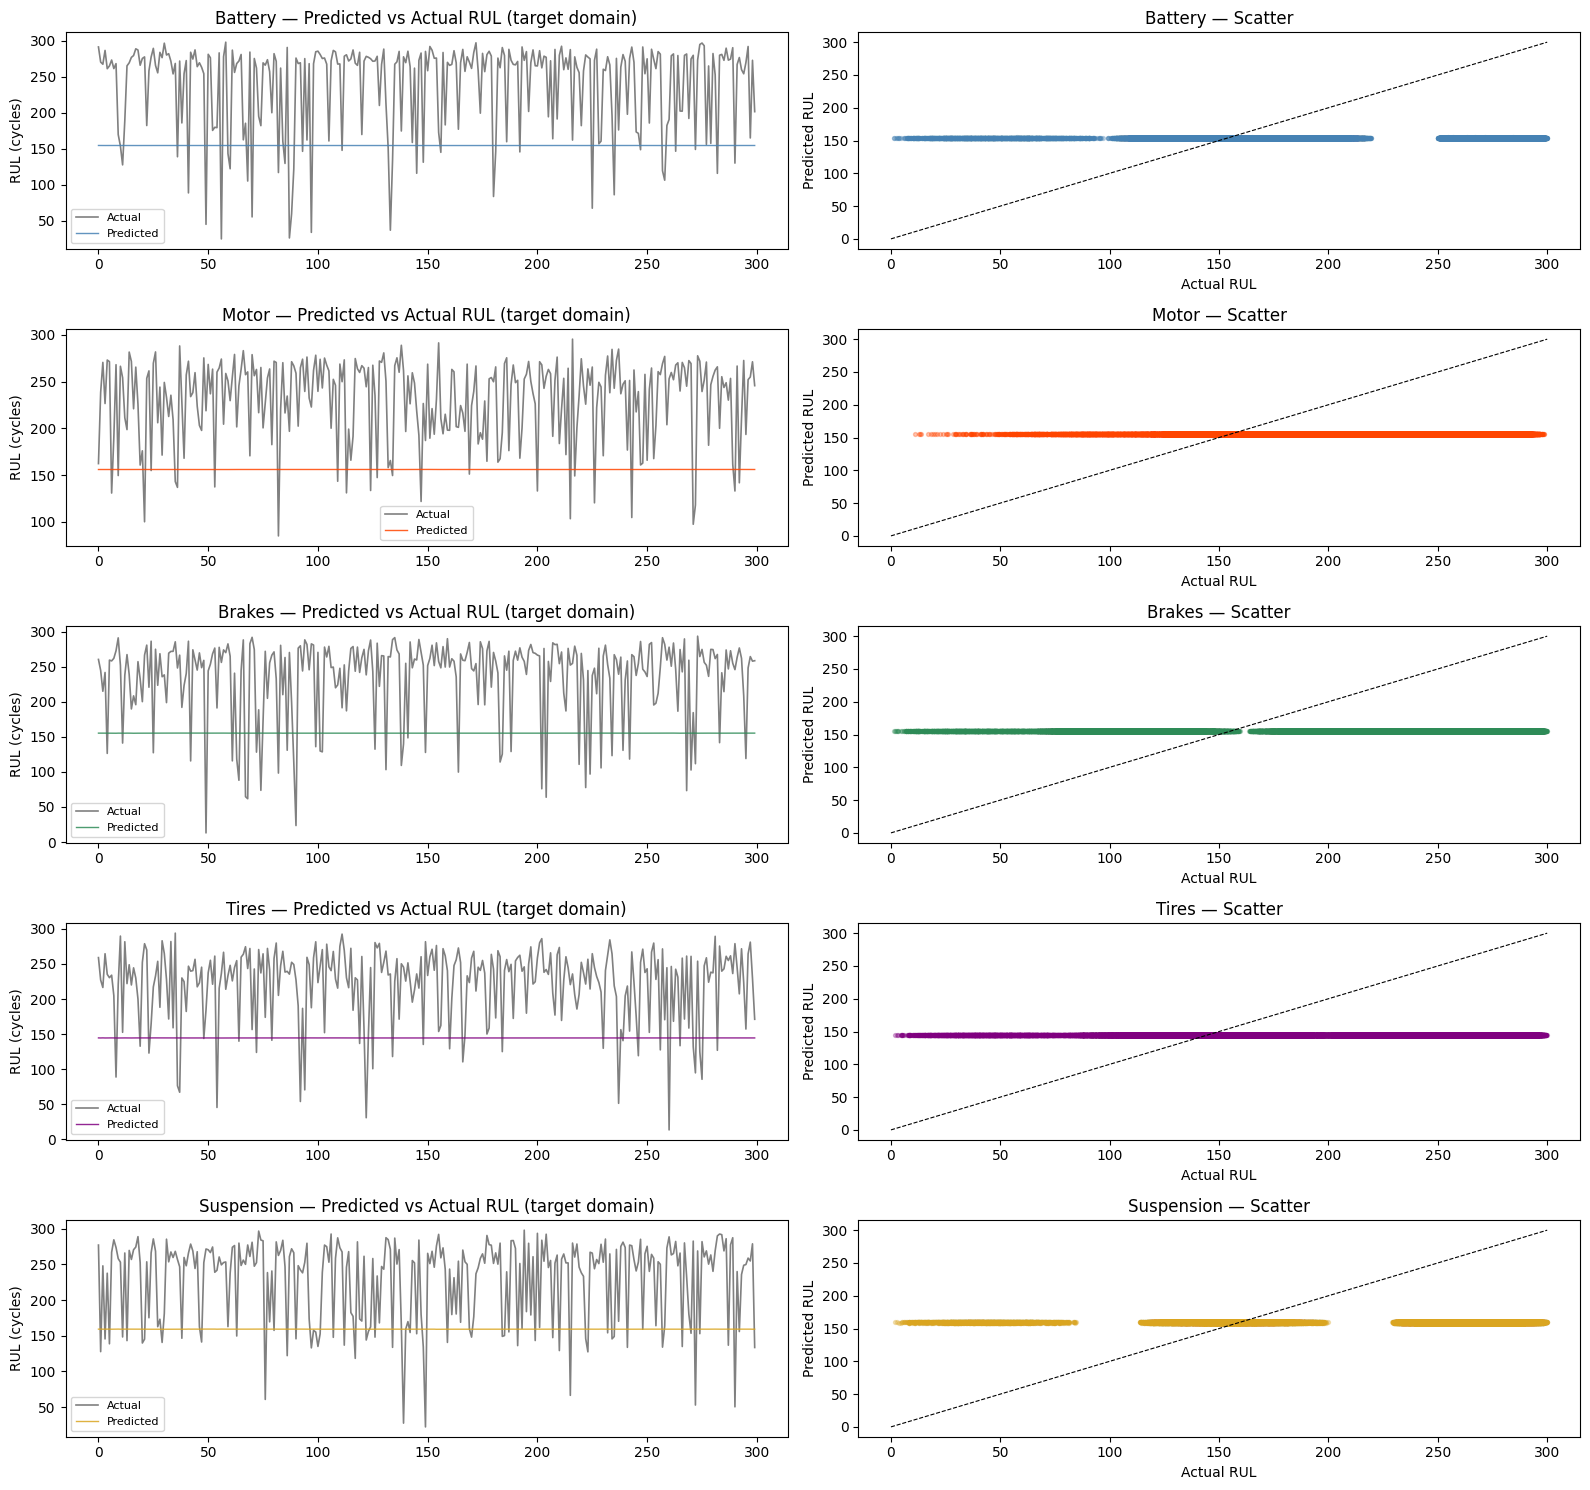

In [15]:
colors = ['steelblue', 'orangered', 'seagreen', 'purple', 'goldenrod']
fig, axes = plt.subplots(N_COMPONENTS, 2, figsize=(16, N_COMPONENTS * 3))

for i, (name, color) in enumerate(zip(COMPONENT_NAMES, colors)):
    tgt_p = tgt_results[name]['preds']
    tgt_l = tgt_results[name]['labels']
    n     = min(300, len(tgt_l))

    # Time series
    axes[i, 0].plot(tgt_l[:n], label='Actual',    color='gray',  linewidth=1.2)
    axes[i, 0].plot(tgt_p[:n], label='Predicted', color=color,   linewidth=1.0, alpha=0.85)
    axes[i, 0].set_title(f'{name} — Predicted vs Actual RUL (target domain)')
    axes[i, 0].set_ylabel('RUL (cycles)'); axes[i, 0].legend(fontsize=8)

    # Scatter
    axes[i, 1].scatter(tgt_l, tgt_p, s=8, alpha=0.3, color=color)
    axes[i, 1].plot([0, MAX_RUL], [0, MAX_RUL], 'k--', linewidth=0.8)
    axes[i, 1].set_title(f'{name} — Scatter')
    axes[i, 1].set_xlabel('Actual RUL'); axes[i, 1].set_ylabel('Predicted RUL')

plt.tight_layout()
plt.savefig('../results/component_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. t-SNE Feature Space

In [ ]:
from sklearn.manifold import TSNE

def extract_features(loader, model, device):
    model.eval()
    feats = []
    with torch.no_grad():
        for x, _, _ in loader:
            feats.append(model.feature_extractor(x.to(device)).cpu().numpy())
    return np.concatenate(feats)

n = 400
src_feats = extract_features(src_val_loader, model, DEVICE)[:n]
tgt_feats = extract_features(tgt_val_loader, model, DEVICE)[:n]
all_feats  = np.concatenate([src_feats, tgt_feats])
all_labels = ['Source'] * len(src_feats) + ['Target'] * len(tgt_feats)

emb = TSNE(n_components=2, random_state=SEED, perplexity=30).fit_transform(all_feats)

plt.figure(figsize=(7, 6))
for label, color in [('Source', 'steelblue'), ('Target', 'orangered')]:
    mask = np.array([l == label for l in all_labels])
    plt.scatter(emb[mask, 0], emb[mask, 1], s=12, alpha=0.5, color=color, label=label)
plt.title('t-SNE of CNN Features — Source vs Target\n(well-mixed = good domain adaptation)')
plt.legend()
plt.tight_layout()
plt.savefig('../results/tsne_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Save Model & Scaler

In [ ]:
torch.save(model.state_dict(), '../models/cnn_dann_rul.pth')
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('Saved: ../models/cnn_dann_rul.pth')
print('Saved: ../models/scaler.pkl')

## 13. Inference on New Data

In [ ]:
def predict_rul(raw_window_df, model, scaler,
                sensor_cols=SENSOR_COLS, component_names=COMPONENT_NAMES,
                window_size=WINDOW_SIZE, max_rul=MAX_RUL, device=DEVICE):
    """
    Predict RUL for all 5 components from a single window of raw sensor data.

    Args:
        raw_window_df : pd.DataFrame — exactly `window_size` rows, raw (unscaled) sensor values
    Returns:
        dict: {component_name: predicted_RUL_in_cycles}
    """
    assert len(raw_window_df) == window_size, \
        f'Need exactly {window_size} rows, got {len(raw_window_df)}'

    scaled = scaler.transform(raw_window_df[sensor_cols].values).astype(np.float32)
    x      = torch.tensor(scaled).unsqueeze(0).permute(0, 2, 1).to(device)

    model.eval()
    with torch.no_grad():
        rul_norm, _ = model(x)                       # (1, 5)
    rul_vals = (rul_norm.cpu().numpy()[0] * max_rul).tolist()
    return dict(zip(component_names, rul_vals))


# Example: last 20 rows of raw data
raw_df = pd.read_csv(CSV_PATH).ffill().bfill()
sample_window = raw_df.iloc[-WINDOW_SIZE:][SENSOR_COLS]
predictions   = predict_rul(sample_window, model, scaler)

print('Predicted RUL per component:')
for comp, rul in predictions.items():
    print(f'  {comp:12s}: {rul:.1f} cycles')